In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [10]:
train_dir = "dataset\seg_train\seg_train"
test_dir = "dataset\seg_test\seg_test"

img_size = (224, 224)
batch_size = 32

In [11]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical"
)

val_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical"
)

Found 14034 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


In [12]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

In [13]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(6, activation="softmax")
])

In [14]:
# เปิด trainable
base_model.trainable = True

# Freeze layer แรก ๆ ไว้
for layer in base_model.layers[:-40]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),  # LR ต่ำมาก สำคัญ
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_finetune = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 340s 765ms/step - accuracy: 0.6415 - loss: 0.9797 - val_accuracy: 0.7597 - val_loss: 0.5958
Epoch 2/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 237s 539ms/step - accuracy: 0.8324 - loss: 0.4807 - val_accuracy: 0.8610 - val_loss: 0.3652
Epoch 3/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 236s 538ms/step - accuracy: 0.8589 - loss: 0.3888 - val_accuracy: 0.8810 - val_loss: 0.3000
Epoch 4/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 234s 534ms/step - accuracy: 0.8806 - loss: 0.3399 - val_accuracy: 0.9003 - val_loss: 0.2682
Epoch 5/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 234s 533ms/step - accuracy: 0.8911 - loss: 0.3082 - val_accuracy: 0.8867 - val_loss: 0.2965


In [15]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=[early_stop]
)

Epoch 1/30
439/439 ━━━━━━━━━━━━━━━━━━━━ 448s 1s/step - accuracy: 0.8931 - loss: 0.2975 - val_accuracy: 0.9127 - val_loss: 0.2384
Epoch 2/30
439/439 ━━━━━━━━━━━━━━━━━━━━ 459s 1s/step - accuracy: 0.9002 - loss: 0.2784 - val_accuracy: 0.9167 - val_loss: 0.2266
Epoch 3/30
439/439 ━━━━━━━━━━━━━━━━━━━━ 450s 1s/step - accuracy: 0.9049 - loss: 0.2645 - val_accuracy: 0.9173 - val_loss: 0.2226
Epoch 4/30
439/439 ━━━━━━━━━━━━━━━━━━━━ 450s 1s/step - accuracy: 0.9102 - loss: 0.2583 - val_accuracy: 0.9190 - val_loss: 0.2166
Epoch 5/30
439/439 ━━━━━━━━━━━━━━━━━━━━ 447s 1s/step - accuracy: 0.9161 - loss: 0.2406 - val_accuracy: 0.9213 - val_loss: 0.2092
Epoch 6/30
439/439 ━━━━━━━━━━━━━━━━━━━━ 449s 1s/step - accuracy: 0.9168 - loss: 0.2365 - val_accuracy: 0.9220 - val_loss: 0.2076
Epoch 7/30
439/439 ━━━━━━━━━━━━━━━━━━━━ 456s 1s/step - accuracy: 0.9188 - loss: 0.2292 - val_accuracy: 0.9223 - val_loss: 0.2048
Epoch 8/30
439/439 ━━━━━━━━━━━━━━━━━━━━ 459s 1s/step - accuracy: 0.9228 - loss: 0.2139 - val_accu

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    verbose=1
)

model.fit(..., callbacks=[early_stop, reduce_lr])

{'accuracy': [0.8940430283546448, 0.903448760509491, 0.9048026204109192, 0.9094342589378357, 0.9117144346237183, 0.9186261892318726, 0.9196237921714783, 0.9215476512908936, 0.924397885799408, 0.9297420382499695, 0.9289582371711731, 0.931452214717865, 0.9340173602104187, 0.9349437355995178, 0.9389340281486511, 0.9391477704048157], 'loss': [0.2984514534473419, 0.2801267206668854, 0.2734403908252716, 0.2542819678783417, 0.24825432896614075, 0.23429898917675018, 0.22859838604927063, 0.21988989412784576, 0.2101612687110901, 0.19963127374649048, 0.1978861689567566, 0.19201762974262238, 0.18971896171569824, 0.1783905327320099, 0.17344415187835693, 0.1695869266986847], 'val_accuracy': [0.9163333177566528, 0.9146666526794434, 0.92166668176651, 0.9203333258628845, 0.9223333597183228, 0.9243333339691162, 0.9246666431427002, 0.9276666641235352, 0.9253333210945129, 0.9276666641235352, 0.9286666512489319, 0.9303333163261414, 0.9319999814033508, 0.921999990940094, 0.9279999732971191, 0.92566668987274

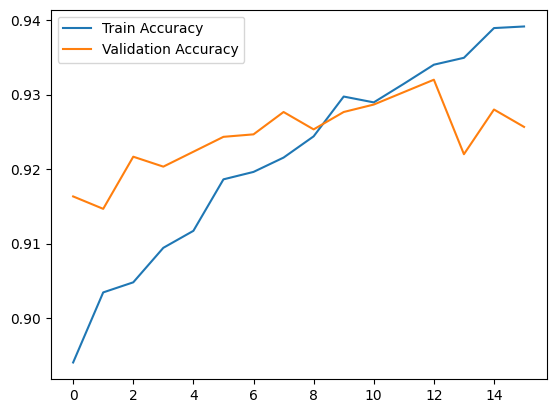

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
print(history.history)
plt.legend()
plt.show()

In [ ]:
model.save("intel_nn_model.h5")
print("Model saved ✅")

Model saved ✅
